# Kepler Analysis - Extended Triangulation for Mars Orbit Determination

This notebook extends our previous Kepler analysis by performing a comprehensive triangulation of **Mars'** orbit using Earth-based **line-of-sight (LOS) measurements**.  
By selecting observations spaced by approximately one Mars year (687 days), we capture multiple perspectives on Mars' position as it returns to a similar solar alignment. These extended measurements enable us to robustly triangulate Mars' orbit over time.

**Contact:** Luca.Canali@cern.ch  
**Date:** February 2025

---
## Workflow Overview

- **Data Ingestion & Preparation**
  - Load the dataset (`line_of_sight_mars_from_earth.csv`) with Mars and Sun observations, notably the following fields: Date, Mars Ecliptic Longitude (deg), and Sun Ecliptic Longitude (deg).

- **Generalized Triangulation**  
  - For each start date within the first Mars year, iterate through subsequent measurements at 687-day intervals (one Mars year), so that Mars is observed at nearly the same position relative to the Sun for each measurement.
  - Triangulate Mars' position from the accumulated data when at least two valid measurements are available.
  - Gracefully handle missing data and singular matrices to ensure robust estimation.

- **Data Export**  
  - Compile the computed Mars positions into a results DataFrame and save the results to a CSV file (`computed_Mars_orbit.csv`) for further analysis.

- **Visualization**  
  - Plot the **Sun** at the origin and depict **Earth’s orbit** as a unit circle (1 AU).
  - Overlay the computed Mars orbit derived from the triangulation process.
  - Annotate key elements to highlight the convergence of estimated Mars positions over time, offering a visual interpretation of the underlying Kepler analysis.


## Triangulate Mars positions from the ephemeris data

In [1]:
import pandas as pd
import numpy as np

# -------------------------------
# 1. Read CSV data and set date as index
# -------------------------------
folder = "../Data/"
csv_filename = "ephemeris_mars_sun.csv"

df = pd.read_csv(folder+csv_filename, parse_dates=["Date"])
df.set_index("Date", inplace=True)
df.sort_index(inplace=True)  # Ensure the data is in chronological order

# -------------------------------
# 2. Define constants and triangulation parameters
# -------------------------------
MARS_YEAR_DAYS = 687  # Duration of a Mars year in days
interval = pd.Timedelta(days=MARS_YEAR_DAYS)

# -------------------------------
# 3. Generate daily start dates from first_date to first_date + MARS_YEAR_DAYS
# -------------------------------
first_date = df.index[0]
end_date_for_start = first_date + pd.Timedelta(days=MARS_YEAR_DAYS)
start_dates = pd.date_range(start=first_date, end=end_date_for_start, freq='D')

results = []
I = np.eye(2)
deg_to_rad = np.pi / 180.0  # Conversion factor from degrees to radians

for start_date in start_dates:
    A_total = np.zeros((2, 2))
    b_total = np.zeros(2)
    measurement_count = 0  # Count valid measurements used

    i = 0  # Mars-year offset multiplier
    while True:
        meas_date = start_date + i * interval
        
        # Stop if the computed measurement date exceeds available data
        if meas_date > df.index.max():
            break

        if meas_date in df.index:
            row = df.loc[meas_date]
            
            # Check if required columns are available
            if pd.isnull(row["Sun Ecliptic Longitude (deg)"]) or pd.isnull(row["Mars Ecliptic Longitude (deg)"]):
                i += 1
                continue

            # --- Compute Earth's heliocentric ecliptic position ---
            sun_eclip_lon_deg = row["Sun Ecliptic Longitude (deg)"]
            # Earth’s ecliptic longitude is the Sun’s apparent longitude plus 180° (modulo 360)
            earth_eclip_lon_deg = (sun_eclip_lon_deg + 180) % 360
            earth_eclip_lon_rad = earth_eclip_lon_deg * deg_to_rad
            E = np.array([np.cos(earth_eclip_lon_rad), np.sin(earth_eclip_lon_rad)])
            
            # --- Compute Mars's geocentric line-of-sight (LOS) unit vector ---
            mars_eclip_lon_deg = row["Mars Ecliptic Longitude (deg)"]
            mars_eclip_lon_rad = mars_eclip_lon_deg * deg_to_rad
            v = np.array([np.cos(mars_eclip_lon_rad), np.sin(mars_eclip_lon_rad)])
            
            # Accumulate the projection matrix contribution: A_i = I - v v^T
            A_i = I - np.outer(v, v)
            A_total += A_i
            b_total += A_i @ E
            measurement_count += 1

        i += 1  # Increment the Mars-year offset

    # Require at least two valid measurements
    if measurement_count < 2:
        print(f"Skipping start date {start_date.date()} (insufficient data: {measurement_count} measurement(s)).")
        continue

    try:
        # Solve for Mars' heliocentric position M_est
        M_est = np.linalg.solve(A_total, b_total)
    except np.linalg.LinAlgError:
        print(f"Skipping start date {start_date.date()} due to a singular matrix.")
        continue

    results.append({
        "Start_Date": start_date,
        "Mars_X": M_est[0],
        "Mars_Y": M_est[1],
        "Measurements_used": measurement_count
    })


# -------------------------------
# 5. Create and display the results DataFrame
# -------------------------------
df_results = pd.DataFrame(results)
print(df_results)


    Start_Date    Mars_X    Mars_Y  Measurements_used
0   2000-01-01  1.387911 -0.007656                 11
1   2000-01-02  1.390132  0.006632                 10
2   2000-01-03  1.391546  0.020397                 11
3   2000-01-04  1.391945  0.035610                 11
4   2000-01-05  1.392190  0.050820                 11
..         ...       ...       ...                ...
683 2001-11-14  1.383289 -0.068702                 10
684 2001-11-15  1.384593 -0.053520                 10
685 2001-11-16  1.385745 -0.038333                 10
686 2001-11-17  1.386745 -0.023141                 10
687 2001-11-18  1.387593 -0.007947                 10

[688 rows x 4 columns]


In [2]:
# Save the DataFrame to a CSV file

folder = "../Data/"
csv_filename = "computed_Mars_orbit.csv"

df_results.index.name = "Day N#"
df_results.to_csv(folder+csv_filename, index=True)
print(f"Computed Mars position vs time in the plane of ecliptic successfully saved to {csv_filename}")


Computed Mars position vs time in the plane of ecliptic successfully saved to computed_Mars_orbit.csv


## Visualization of Mars Orbit

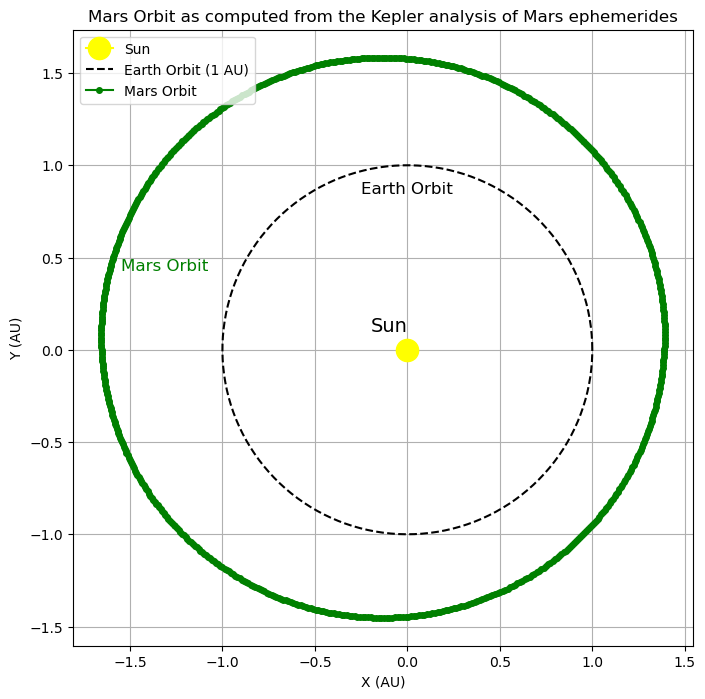

In [3]:
# -------------------------------
# 6. Visualization: Plot Sun, Earth's Orbit, and Mars Orbit (in green)
# -------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

# Plot the Sun at the origin
plt.plot(0, 0, marker='o', color='yellow', markersize=16, label='Sun')
plt.text(-0.2, 0.1, 'Sun', fontsize=14, color='black')

# Plot Earth's orbit (unit circle)
theta = np.linspace(0, 2*np.pi, 300)
plt.plot(np.cos(theta), np.sin(theta), 'k--', label='Earth Orbit (1 AU)')
# Manually position the Earth orbit label (e.g., near the first quadrant)
plt.text(-.25, .85, 'Earth Orbit', fontsize=12, color='black')

# Plot the estimated Mars orbit in green
plt.plot(df_results["Mars_X"], df_results["Mars_Y"], 'g.-', label="Mars Orbit", markersize=8)
# Place a text label along the Mars orbit (e.g., at the middle of the data series)
if not df_results.empty:
    mid_idx = len(df_results) // 2
    plt.text(df_results["Mars_X"].iloc[mid_idx] + 0.1,
             df_results["Mars_Y"].iloc[mid_idx] + 0.2,
             'Mars Orbit', fontsize=12, color='green')

plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.title("Mars Orbit as computed from the Kepler analysis of Mars ephemerides")
# Place the legend in the lower right so it doesn't overlap with Mars data.
plt.legend(loc="upper left")
plt.axis("equal")
plt.grid(True)
plt.show()
